Team : Anna Moy & Natalie Kalukeerthie

The Simpsons is a popular animated sitcom enjoyed by audiences worldwide. It first premiered in 1989 and has become one of the longest-running television shows in the United States. We chose this dataset because we both watched the show as children, and it is iconic. We can relate to it, even though we belong to different generations.

The dataset we used is from Kaggle: Dialogue Lines of The Simpsons

https://www.kaggle.com/datasets/pierremegret/dialogue-lines-of-the-simpsons?select=simpsons_dataset.csv

The dataset has two columns:

*   Character names
*   Dialogue lines for each character



First, we loaded the data and cleaned up the data by removing any blank rows and trimmed the extra space between the words in the dialogue. Then we looked at the first 5 lines of the data.

In [ ]:
import pandas as pd
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/AnnaMoy/Data-620/refs/heads/main/simpsons_dataset.csv"
df = pd.read_csv(url)

# Clean missing rows
df = df.dropna(subset=['raw_character_text', 'spoken_words'])

# Clean whitespace
df['raw_character_text'] = df['raw_character_text'].str.strip()
df['spoken_words'] = df['spoken_words'].astype(str).str.strip()

print(df.head())



        raw_character_text                                       spoken_words
0              Miss Hoover  No, actually, it was a little of both. Sometim...
1             Lisa Simpson                             Where's Mr. Bergstrom?
2              Miss Hoover  I don't know. Although I'd sure like to talk t...
3             Lisa Simpson                         That life is worth living.
4  Edna Krabappel-Flanders  The polls will be open from now until the end ...


We looked to find out how many lines each character has  and you can see the Simpsons family has more lines than the other non important characters. I took at the top 10 characters with the most dialogue lines.

In [ ]:
# Count number of lines spoken by each character
line_counts = df['raw_character_text'].value_counts()

# Display the counts
print(line_counts)

# top 10 characters with most lines
print("\nTop 10 characters by number of lines:")
print(line_counts.head(10))


raw_character_text
Homer Simpson            27850
Marge Simpson            13172
Bart Simpson             12995
Lisa Simpson             10756
C. Montgomery Burns       3077
                         ...  
St. Sebastian                1
Young Sean                   1
Sean's Dad                   1
Obnoxious Diner              1
Commanding-voiced Man        1
Name: count, Length: 6272, dtype: int64

Top 10 characters by number of lines:
raw_character_text
Homer Simpson          27850
Marge Simpson          13172
Bart Simpson           12995
Lisa Simpson           10756
C. Montgomery Burns     3077
Moe Szyslak             2808
Seymour Skinner         2385
Ned Flanders            2056
Grampa Simpson          1802
Chief Wiggum            1790
Name: count, dtype: int64


Next, we created a network graph. To do this, we assumed that characters are connected if their lines appear within five lines of each other, building a proximity-based interaction network. Based on the network created we took a look to see the number of character and interactions we had which is 6,271 characters and 47,889 interactions.

In [ ]:
# Create an empty graph
G = nx.Graph()

window_size = 5

for i, row in df.iterrows():
    current_char = row['raw_character_text']
    # look ahead a few lines
    nearby = df.iloc[i+1:i+window_size]['raw_character_text'].dropna().unique()

    for other in nearby:
        if other != current_char:
            if G.has_edge(current_char, other):
                G[current_char][other]['weight'] += 1
            else:
                G.add_edge(current_char, other, weight=1)

print(f"Number of characters (nodes): {G.number_of_nodes()}")
print(f"Number of interactions (edges): {G.number_of_edges()}")

Number of characters (nodes): 6271
Number of interactions (edges): 47889


We examined degree centrality to identify the most important characters, which were mainly the Simpson family along with other key characters. This is expected, as the show’s stories are primarily centered around this family that is why their degree of centrality score is much higher compared to other characters.

In [ ]:
# Compute degree centrality
deg_centrality = nx.degree_centrality(G)

# Sort and get top 10 (character, score)
top_chars_centrality = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

# Print results
print("Top 10 characters by degree centrality:")
for char, score in top_chars_centrality:
    print(f"{char}: {score:.3f}")

# Extract just the character names (for later subgraph visualization)
top_chars = [char for char, _ in top_chars_centrality]
print("Most important characters:", top_chars)


Top 10 characters by degree centrality:
Homer Simpson: 0.795
Marge Simpson: 0.603
Bart Simpson: 0.589
Lisa Simpson: 0.548
Moe Szyslak: 0.194
C. Montgomery Burns: 0.185
Seymour Skinner: 0.181
Chief Wiggum: 0.164
Milhouse Van Houten: 0.161
Ned Flanders: 0.156
Most important characters: ['Homer Simpson', 'Marge Simpson', 'Bart Simpson', 'Lisa Simpson', 'Moe Szyslak', 'C. Montgomery Burns', 'Seymour Skinner', 'Chief Wiggum', 'Milhouse Van Houten', 'Ned Flanders']


We visualized the top 10 characters to see the interaction network between the characters and you can see the Simpsons family is centered in the middle.

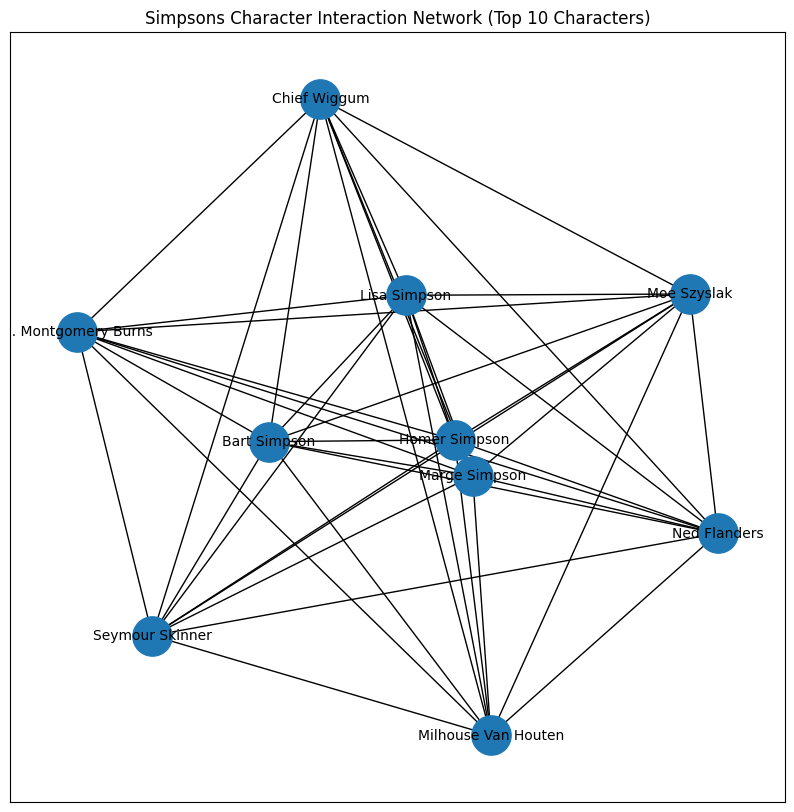

In [ ]:
# Visualize the top 10 characters
subG = G.subgraph(top_chars)

plt.figure(figsize=(10,10))
pos = nx.spring_layout(subG, k=0.3, seed=42)  # add seed
nx.draw_networkx(subG, pos, with_labels=True, node_size=800, font_size=10)
plt.title("Simpsons Character Interaction Network (Top 10 Characters)")
plt.show()



Based on the Simpsons character network, we looked at the diameter, which represents the longest shortest path between any two nodes. In this network, it would take four interactions to connect the two characters that are the furthest apart.

In [ ]:
# Compute diameter of the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
subG = G.subgraph(largest_cc)
diameter = nx.diameter(subG)
print("Diameter of largest connected component:", diameter)

Diameter of largest connected component: 4


On average, the characters interacted with 15 other characters when we took a look at the average degree. Then we wanted to find out if the characters interacted with their neighbors and the result was very low .00073 it is because the neighbor characters are mainly interacting with the main characters which is the Simpsons family.

In [ ]:
# Average degree
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print("Average degree:", avg_degree)

# Average clustering coefficient
avg_clustering = nx.average_clustering(G, weight='weight')
print("Average clustering coefficient:", avg_clustering)


Average degree: 15.273162175091691
Average clustering coefficient: 0.000732812602153967


With our dataset we manually identify 28 characters manually as female or male and labeled all the other characters as other. There were too many characters to identify there might be some bias to the results. We conducted a degree centrality and the result for male and female were fairly similar. This indicates the main characters like Marge, Lisa and Maggie are connected with other characters about 18% of the time. The male characters Homer and Bart is connected to others 17% of the time. There is not much connection between the characters labeled as Others since the degree of centrality was .001812.

gender
Female    0.188540
Male      0.175407
Other     0.001812
Name: degree, dtype: float64


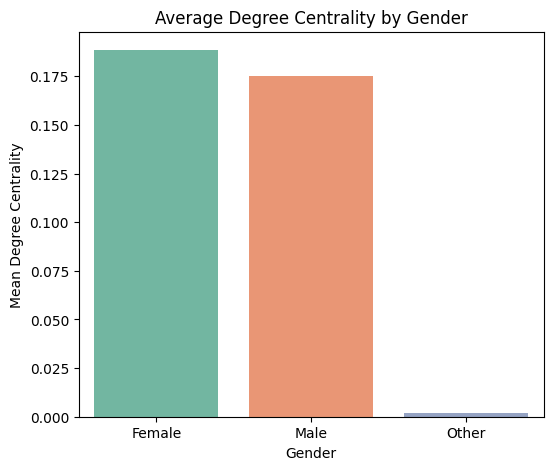

In [ ]:
# Main characters mapping
main_chars_gender = {
    # Main family
    'Homer Simpson': 'Male',
    'Marge Simpson': 'Female',
    'Bart Simpson': 'Male',
    'Lisa Simpson': 'Female',
    'Maggie Simpson': 'Female',

    # Extended family
    'Abe Simpson': 'Male',
    'Patty Bouvier': 'Female',
    'Selma Bouvier': 'Female',

    # School staff
    'Principal Skinner': 'Male',
    'Edna Krabappel': 'Female',
    'Milhouse Van Houten': 'Male',
    'Nelson Muntz': 'Male',
    'Martin Prince': 'Male',

    # Work colleagues
    'Mr. Burns': 'Male',
    'Smithers': 'Male',
    'Carl': 'Male',
    'Lenny': 'Male',

    # Townspeople
    'Moe Szyslak': 'Male',
    'Ned Flanders': 'Male',
    'Maude Flanders': 'Female',
    'Krusty the Clown': 'Male',
    'Apu Nahasapeemapetilon': 'Male',
    'Chief Wiggum': 'Male',
    'Ralph Wiggum': 'Male',
    'Comic Book Guy': 'Male',
    'Barney Gumble': 'Male',
    'Reverend Lovejoy': 'Male',
    'Helen Lovejoy': 'Female'
}


# Assign gender attribute
gender_map = {}
for node in G.nodes():
    if node in main_chars_gender:
        gender_map[node] = main_chars_gender[node]
    else:
        gender_map[node] = 'Other'  # All other minor/guest characters

nx.set_node_attributes(G, gender_map, 'gender')

data = pd.DataFrame({
    'character': list(G.nodes()),
    'gender': [G.nodes[n]['gender'] for n in G.nodes()],
    'degree': [nx.degree_centrality(G)[n] for n in G.nodes()]
})

# Compare mean degree centrality by category
print(data.groupby('gender')['degree'].mean())

gender_means = data.groupby('gender')['degree'].mean().reset_index()

plt.figure(figsize=(6,5))
sns.barplot(x='gender', y='degree', data=gender_means, hue='gender', legend=False, palette='Set2')
plt.title("Average Degree Centrality by Gender")
plt.ylabel("Mean Degree Centrality")
plt.xlabel("Gender")
plt.show()


We turned out dataset into a corpus for us to be able to look at the total number of words which is 1,027,251 and the number of unique words on our file which s 38,175. We kept only alphabetic words, removed punctuations, numbers and replaced the contraction words with the full word.

In [ ]:
import re
from collections import Counter

# Combine all lines
corpus = " ".join(df['spoken_words'].str.lower())

# Handle tricky contractions first
contraction_patterns_special = {
    r"\bcan't\b": "cannot",
    r"\bwon't\b": "will not",
    r"\bshan't\b": "shall not",
}

for pattern, repl in contraction_patterns_special.items():
    corpus = re.sub(pattern, repl, corpus)

# General contractions
contraction_patterns = {
    r"\b(\w+)'s\b": r"\1 is",
    r"\b(\w+)'re\b": r"\1 are",
    r"\b(\w+)'ll\b": r"\1 will",
    r"\b(\w+)'ve\b": r"\1 have",
    r"\b(\w+)n't\b": r"\1 not",
    r"\bi'm\b": "i am",
}

for pattern, repl in contraction_patterns.items():
    corpus = re.sub(pattern, repl, corpus)

# Tokenize: keep only alphabetic tokens
tokens = re.findall(r'\b[a-z]+\b', corpus)

# Remove very short tokens (length <=2) to remove fragments like 'ca', 'od', 'uh'
tokens = [t for t in tokens if len(t) > 2]

# Count word frequencies
counter = Counter(tokens)
total_words = sum(counter.values())
unique_words = len(counter)

print(f"Total words: {total_words}")
print(f"Unique words: {unique_words}")



Total words: 1027251
Unique words: 38175


We looked at how many unique words would make up half of the corpuus and it took 79 unique words to make up half of the corpus and displayed the words.

In [ ]:
# Determine how many unique words represent half of the corpus
sorted_words = counter.most_common()
cumulative_count = 0
half_words = []
for word, freq in sorted_words:
    cumulative_count += freq
    half_words.append(word)
    if cumulative_count >= total_words / 2:
        break
print(f"Number of unique words representing half of the corpus: {len(half_words)}")
print("Words:", half_words)

Number of unique words representing half of the corpus: 123
Words: ['you', 'the', 'and', 'not', 'that', 'are', 'have', 'this', 'your', 'for', 'will', 'what', 'but', 'all', 'just', 'with', 'well', 'now', 'like', 'was', 'get', 'here', 'can', 'one', 'there', 'know', 'out', 'they', 'hey', 'homer', 'right', 'did', 'got', 'how', 'bart', 'our', 'about', 'let', 'who', 'from', 'good', 'see', 'yeah', 'think', 'why', 'cannot', 'want', 'man', 'could', 'marge', 'look', 'dad', 'gonna', 'back', 'little', 'would', 'time', 'okay', 'some', 'when', 'him', 'come', 'take', 'never', 'his', 'simpson', 'lisa', 'say', 'where', 'she', 'make', 'yes', 'more', 'really', 'been', 'has', 'two', 'her', 'love', 'going', 'way', 'were', 'down', 'off', 'only', 'too', 'then', 'something', 'boy', 'had', 'people', 'need', 'sorry', 'over', 'day', 'should', 'those', 'these', 'tell', 'please', 'sure', 'mom', 'thing', 'them', 'give', 'does', 'new', 'kids', 'wait', 'god', 'first', 'great', 'ever', 'old', 'better', 'stop', 'any', 

We wanted to take a look at the top 200 frequent words but we displayed only the top 30 words visually on a chart.

Top 200 words:  [('you', 44952), ('the', 41970), ('and', 19348), ('not', 19309), ('that', 17353), ('are', 15148), ('have', 12516), ('this', 11710), ('your', 10457), ('for', 10150), ('will', 9855), ('what', 9359), ('but', 7382), ('all', 6822), ('just', 6677), ('with', 6429), ('well', 6101), ('now', 6030), ('like', 5995), ('was', 5808), ('get', 5237), ('here', 5011), ('can', 4994), ('one', 4967), ('there', 4910), ('know', 4826), ('out', 4530), ('they', 4470), ('hey', 4343), ('homer', 4232), ('right', 4049), ('did', 3801), ('got', 3714), ('how', 3632), ('bart', 3585), ('our', 3374), ('about', 3302), ('let', 3215), ('who', 3095), ('from', 3060), ('good', 3051), ('see', 3024), ('yeah', 2984), ('think', 2841), ('why', 2814), ('cannot', 2785), ('want', 2777), ('man', 2764), ('could', 2746), ('marge', 2707), ('look', 2685), ('dad', 2645), ('gonna', 2631), ('back', 2588), ('little', 2579), ('would', 2522), ('time', 2514), ('okay', 2466), ('some', 2455), ('when', 2430), ('him', 2410), ('come', 2

/tmp/ipython-input-2029221640.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_words), y=list(top_freqs), palette="viridis")


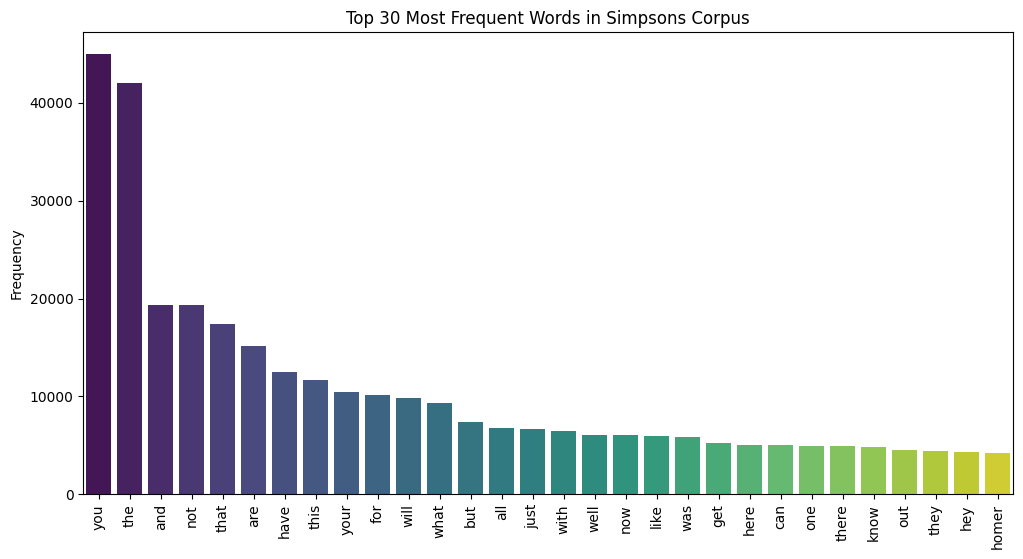

In [ ]:
# Top 200 most frequent words
top_200 = sorted_words[:200]
print(f"Top 200 words: ", top_200)

# Visualize top 30 words
top_words, top_freqs = zip(*top_200[:30])
plt.figure(figsize=(12,6))
sns.barplot(x=list(top_words), y=list(top_freqs), palette="viridis")
plt.xticks(rotation=90)
plt.title("Top 30 Most Frequent Words in Simpsons Corpus")
plt.ylabel("Frequency")
plt.show()

To check if the relative word frequencies follow Zipf’s law, we plotted the data on a log-log scale. If the plot forms a roughly straight line, it indicates that Zipf’s law holds true for the corpus. In the graph below, the line is relatively straight, which suggests that the corpus follows Zipf’s law.This helps us confirm it is a natural language.

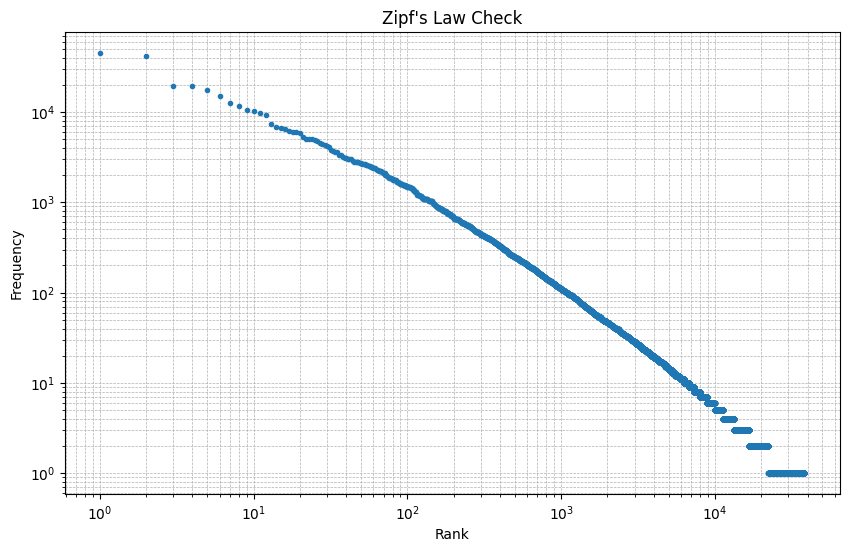

In [ ]:
# Sort words by frequency
sorted_counts = counter.most_common()  # full list of (word, frequency)

# Ranks and frequencies for Zipf's Law
ranks = np.arange(1, len(sorted_counts) + 1)
frequencies = np.array([freq for word, freq in sorted_counts])

# Plot log-log plot to check Zipf's Law
plt.figure(figsize=(10,6))
plt.loglog(ranks, frequencies, marker="o", markersize=3, linestyle='none')
plt.title("Zipf's Law Check")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

Looking at the dialogue of the Simpsons we wanted to see which character has the most positive or negative sentiment based on their logs. It was a bit suprising to see Ned Flanders and Mr. Burns had the highest positive lines and Grampa Simpson and Chief Wiggum had the highest negative lines. I would have expected Mr. Burns who looks more like a negative character to have the highest negative sentiment.

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


sentiment_label      pct_positive  pct_negative
raw_character_text                             
Homer Simpson            0.355045      0.204632
Marge Simpson            0.359399      0.195566
Bart Simpson             0.320739      0.205618
Lisa Simpson             0.326237      0.209186
C. Montgomery Burns      0.408515      0.225869
Moe Szyslak              0.392806      0.221866
Seymour Skinner          0.378197      0.220545
Ned Flanders             0.415856      0.185798
Grampa Simpson           0.318535      0.235294
Chief Wiggum             0.370950      0.235754


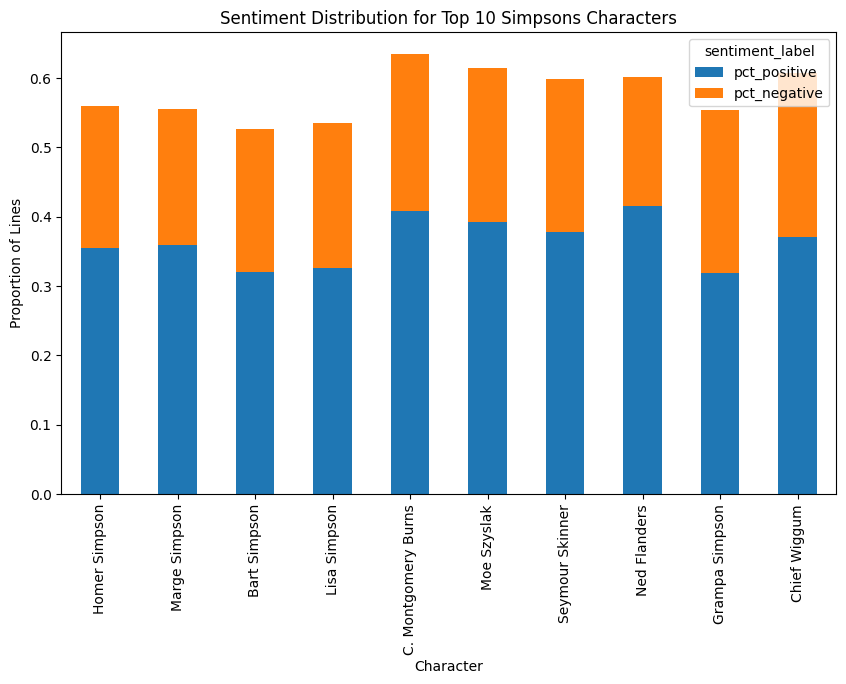

In [ ]:
import nltk
# Download the VADER lexicon
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Compute sentiment scores for each line
df['sentiment_score'] = df['spoken_words'].apply(lambda x: sid.polarity_scores(x)['compound'])

# Classify as positive (>0), negative (<0), neutral (=0)
df['sentiment_label'] = df['sentiment_score'].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'neutral'))

# Aggregate by character: count positive/negative/neutral lines
char_sentiment = df.groupby(['raw_character_text', 'sentiment_label']).size().unstack(fill_value=0)

# Compute % of positive and negative lines
char_sentiment['total'] = char_sentiment.sum(axis=1)
char_sentiment['pct_positive'] = char_sentiment['positive'] / char_sentiment['total']
char_sentiment['pct_negative'] = char_sentiment['negative'] / char_sentiment['total']

# Show top characters with most lines
top_chars = df['raw_character_text'].value_counts().head(10).index
char_sentiment_top = char_sentiment.loc[top_chars]

print(char_sentiment_top[['pct_positive', 'pct_negative']])

# Plot sentiment percentages for top characters
char_sentiment_top[['pct_positive', 'pct_negative']].plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Sentiment Distribution for Top 10 Simpsons Characters")
plt.ylabel("Proportion of Lines")
plt.xlabel("Character")
plt.show()



We conduct a machine learning model to see how well it can predict the character based on the text. We only looked at the words spoken by the top 5 characters using multinomial Naive Bayes based on the TF-IDF features (converts our text to numeric features). Based on results it shows the model was better in predicting the lines for Marge Simpson and Homer Simpson has the highest recall.

Precision - Of all the lines predicted for a character, how many were actually that character?

Recall - Of all the lines spoken by the character, how many were predicted correctly

F1-score - The balance between the precision and recall.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                precision    recall  f1-score   support

  Bart Simpson       0.53      0.20      0.28      2579
 Homer Simpson       0.49      0.92      0.64      5557
  Lisa Simpson       0.52      0.15      0.24      2188
Maggie Simpson       0.00      0.00      0.00         1
 Marge Simpson       0.60      0.23      0.33      2632

      accuracy                           0.50     12957
     macro avg       0.43      0.30      0.30     12957
  weighted avg       0.53      0.50      0.44     12957



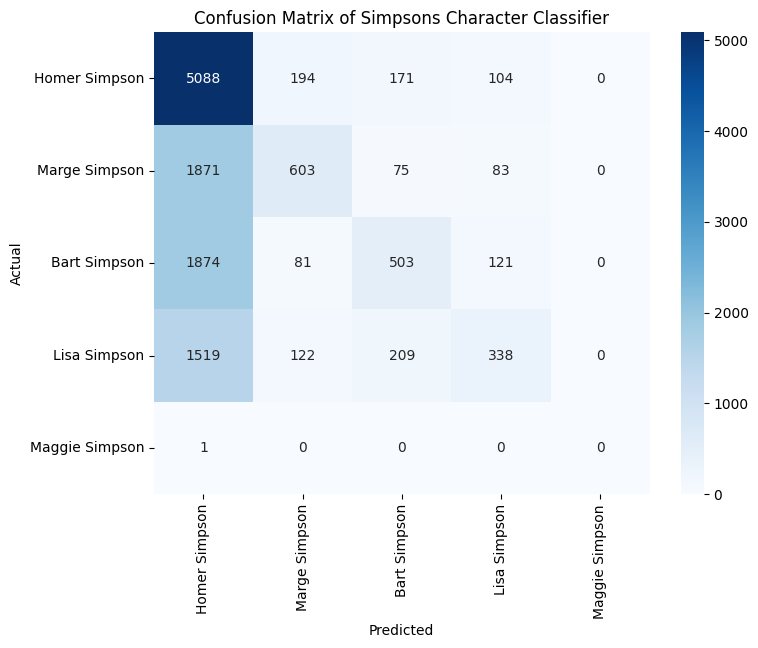

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Top 5 main characters
main_chars = ["Homer Simpson", "Marge Simpson", "Bart Simpson", "Lisa Simpson", "Maggie Simpson"]
df_filtered = df[df['raw_character_text'].isin(main_chars)]

# Text & labels
X = df_filtered['spoken_words']
y = df_filtered['raw_character_text']

# TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = vectorizer.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Train classifier
clf = MultinomialNB()
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=main_chars)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=main_chars, yticklabels=main_chars, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Simpsons Character Classifier")
plt.show()
